# Tổng quan
## Giới thiệu

- Titanic - Machine Learning from Disaster là một trong những cuộc thi khởi đầu (Getting Started Competition) phổ biến nhất trên Kaggle, được coi là "Hello world" của Khoa học Dữ liệu (Data Science) và Học máy (Machine Learning) với dữ liệu dạng bảng.

- Bài toán dựa trên thảm kịch đắm tàu RMS Titanic vào ngày 15 tháng 4 năm 1912, một trong những vụ đắm tàu nổi tiếng nhất lịch sử. Do không đủ thuyền cứu sinh, 1502 trong số 2224 hành khách và thủy thủ đoàn đã thiệt mạng.

- Mặc dù sự sống sót có yếu tố may rủi, nhưng một số nhóm người có vẻ có nhiều khả năng sống sót hơn những nhóm khác (ví dụ: phụ nữ, trẻ em, hành khách hạng nhất).

## Mục tiêu bài toán

- Mục tiêu của dự án là xây dựng một mô hình dự đoán để trả lời câu hỏi: "Những người như thế nào có khả năng sống sót sau thảm họa Titanic?"

- Đây là một bài toán phân loại nhị phân (Binary Classification), trong đó mô hình cần dự đoán xem một hành khách có sống sót hay không

## Bộ dữ liệu Titanic
Bộ dữ liệu cung cấp thông tin chi tiết về các hành khách trên tàu, bao gồm các đặc trưng chính (features) như:
- Survived: Cột mục tiêu (Target Label). Giá trị $0$ = Không sống sót, $1$ = Sống sót.
- Pclass: Hạng vé (tượng trưng cho địa vị kinh tế-xã hội). $1$ = Hạng Nhất (Upper), $2$ = Hạng Trung (Middle), $3$ = Hạng Thấp (Lower).
- Sex: Giới tính.Age: Tuổi của hành khách.
- SibSp: Số lượng anh/chị/em hoặc vợ/chồng cùng đi trên tàu.
- Parch: Số lượng cha mẹ hoặc con cái cùng đi trên tàu.
- Fare: Giá vé.Embarked: Cảng lên tàu.Và một số cột thông tin khác như Name (Tên), Ticket (Số vé), Cabin (Cabin).

In [154]:
import pandas as pd     # for handle dataset
import numpy as np      # math, numeric operate
import matplotlib.pyplot as plt     # draw, plot   
import seaborn as sns               # draw, plot with color
from IPython import display
import warnings
warnings.filterwarnings('ignore')

import datetime
import os


In [ ]:
# Create timestamp 
timestamp = datetime.datetime.now().strftime("%Y%m%d%H%M%S")
# Get the current file name 
# filename = os.path.basename(__file__).replace(".ipynb", "")
filename = "hello-titanic_V5_"

In [156]:
train_data = pd.read_csv("./train.csv")

train_data.tail(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0000,1,1,11751,52.5542,D35,S
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0000,0,0,695,5.0000,B51 B53 B55,S
873,874,0,3,"Vander Cruyssen, Mr. Victor",male,47.0000,0,0,345765,9.0000,NaN,S
874,875,1,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0000,1,0,P/PP 3381,24.0000,NaN,C
875,876,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0000,0,0,2667,7.2250,NaN,C
876,877,0,3,"Gustafsson, Mr. Alfred Ossian",male,20.0000,0,0,7534,9.8458,NaN,S
877,878,0,3,"Petroff, Mr. Nedelio",male,19.0000,0,0,349212,7.8958,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0000,0,1,11767,83.1583,C50,C
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0000,0,1,230433,26.0000,NaN,S


# 1. EDA

In [157]:
path_figures = "./reports/figures"
path_exp = "./reports/experiments"

## 1.1 Non-grapical

In [158]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


- There are some attributes like 'name, sex, ticket, cabin, embarked' are object (string)
- So, should i rescale them?

In [159]:
# Check for missing value
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

- We have 177 rows of 'Age' and 687 rows of 'Cabin' is NaN
- So, should i remove 'Cabin' columns?

In [160]:
# Set precision to 4 decimal places:
pd.options.display.float_format = '{:.4f}'.format

description = train_data.describe()
description

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.0000,891.0000,891.0000,714.0000,891.0000,891.0000,891.0000
mean,446.0000,0.3838,2.3086,29.6991,0.5230,0.3816,32.2042
std,257.3538,0.4866,0.8361,14.5265,1.1027,0.8061,49.6934
min,1.0000,0.0000,1.0000,0.4200,0.0000,0.0000,0.0000
25%,223.5000,0.0000,2.0000,20.1250,0.0000,0.0000,7.9104
50%,446.0000,0.0000,3.0000,28.0000,0.0000,0.0000,14.4542
75%,668.5000,1.0000,3.0000,38.0000,1.0000,0.0000,31.0000
max,891.0000,1.0000,3.0000,80.0000,8.0000,6.0000,512.3292


- Tại sao có một số vé có giá bằng 0? Có phải đó là giá vé trẻ em?

## 1.2 Graphical

### Survival count

Class count:  Survived
0    549
1    342
Name: count, dtype: int64


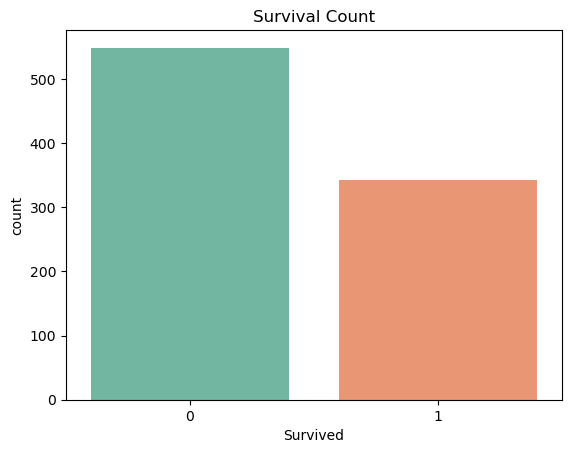

In [161]:
class_count = train_data['Survived'].value_counts()
print("Class count: ", class_count)
# Set the title of the plot
sns.countplot(x=train_data['Survived'], palette="Set2")
plt.title("Survival Count")
# Save the figure
plt.savefig(f"{path_figures}/survived_countplot.png")
plt.show();

### Correlations & visualize

In [162]:
# Correlations:
data_corr = train_data.corr(method='pearson', numeric_only=True)

data_corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.0000,-0.0050,-0.0351,0.0368,-0.0575,-0.0017,0.0127
Survived,-0.0050,1.0000,-0.3385,-0.0772,-0.0353,0.0816,0.2573
Pclass,-0.0351,-0.3385,1.0000,-0.3692,0.0831,0.0184,-0.5495
Age,0.0368,-0.0772,-0.3692,1.0000,-0.3082,-0.1891,0.0961
SibSp,-0.0575,-0.0353,0.0831,-0.3082,1.0000,0.4148,0.1597
Parch,-0.0017,0.0816,0.0184,-0.1891,0.4148,1.0000,0.2162
Fare,0.0127,0.2573,-0.5495,0.0961,0.1597,0.2162,1.0000


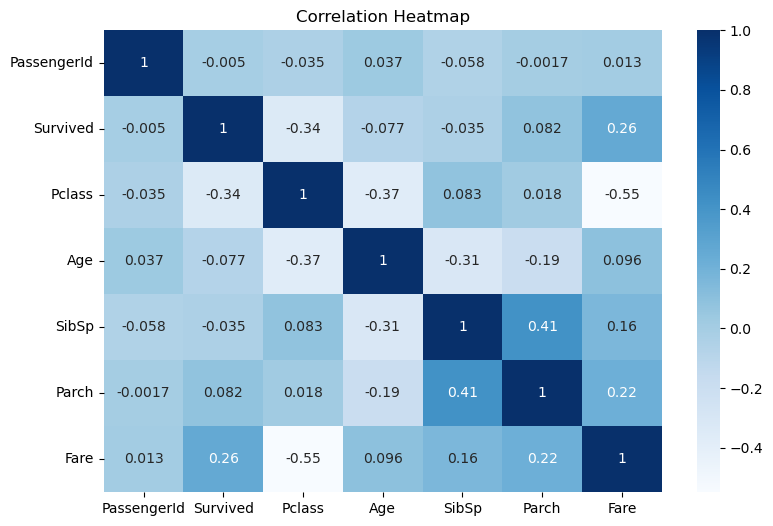

In [163]:
plt.figure(figsize=(9, 6))
sns.heatmap(data_corr, annot=True, cmap='Blues')
# Save the figure
plt.savefig(f"{path_figures}/correlation_heatmap.png")
plt.title('Correlation Heatmap')
plt.show();

- Nhận thấy rằng:
    + 'fare' có tương quan (+) và pclass có tương quan (-) với 'Survived'
      &rarr; Giá vé càng cao hay loại vé càng cao cấp (càng thấp theo Ordical) thì tỉ lệ sống càng cao.
    + 'fare' và 'pclass' có tương quan mạnh ngược, có nghĩa là vé càng cao cấp thì giá càng cao

### Distribution & visualize with histogram, boxplot

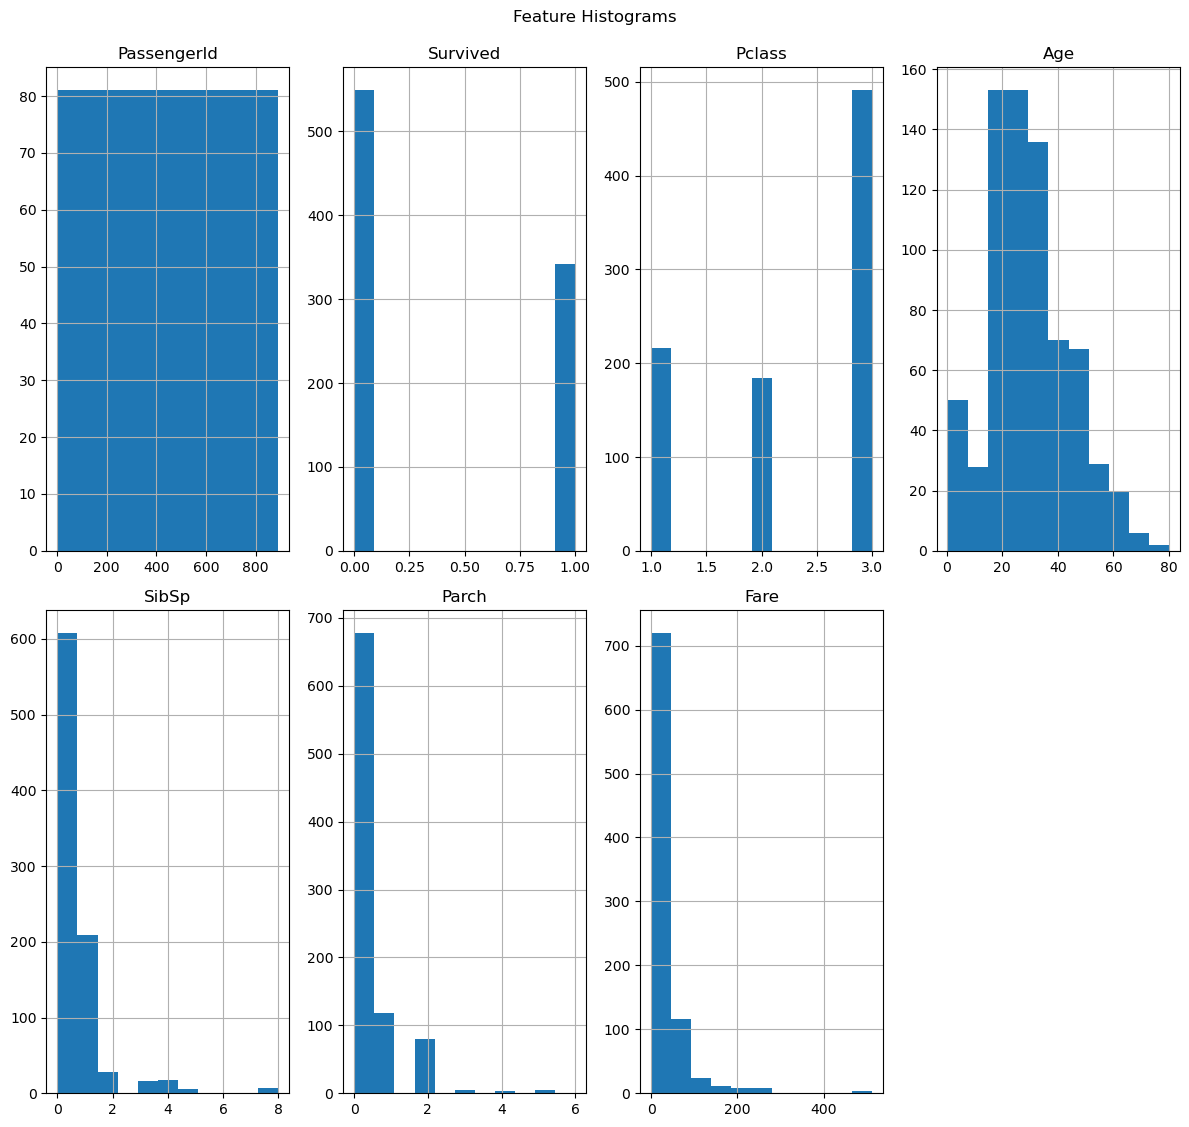

In [164]:
# Distribution with histogram
ax = train_data.hist(figsize=(12, 11), bins=11, layout=(2, 4))
plt.tight_layout()      # auto adjust space between subplots
plt.suptitle('Feature Histograms', y=1.02)
# Save the figure
plt.savefig(f"{path_figures}/feature_histograms.png")
plt.show();

- Comment: các phân phối hầu hết bị lệch phải (Right-skewed)

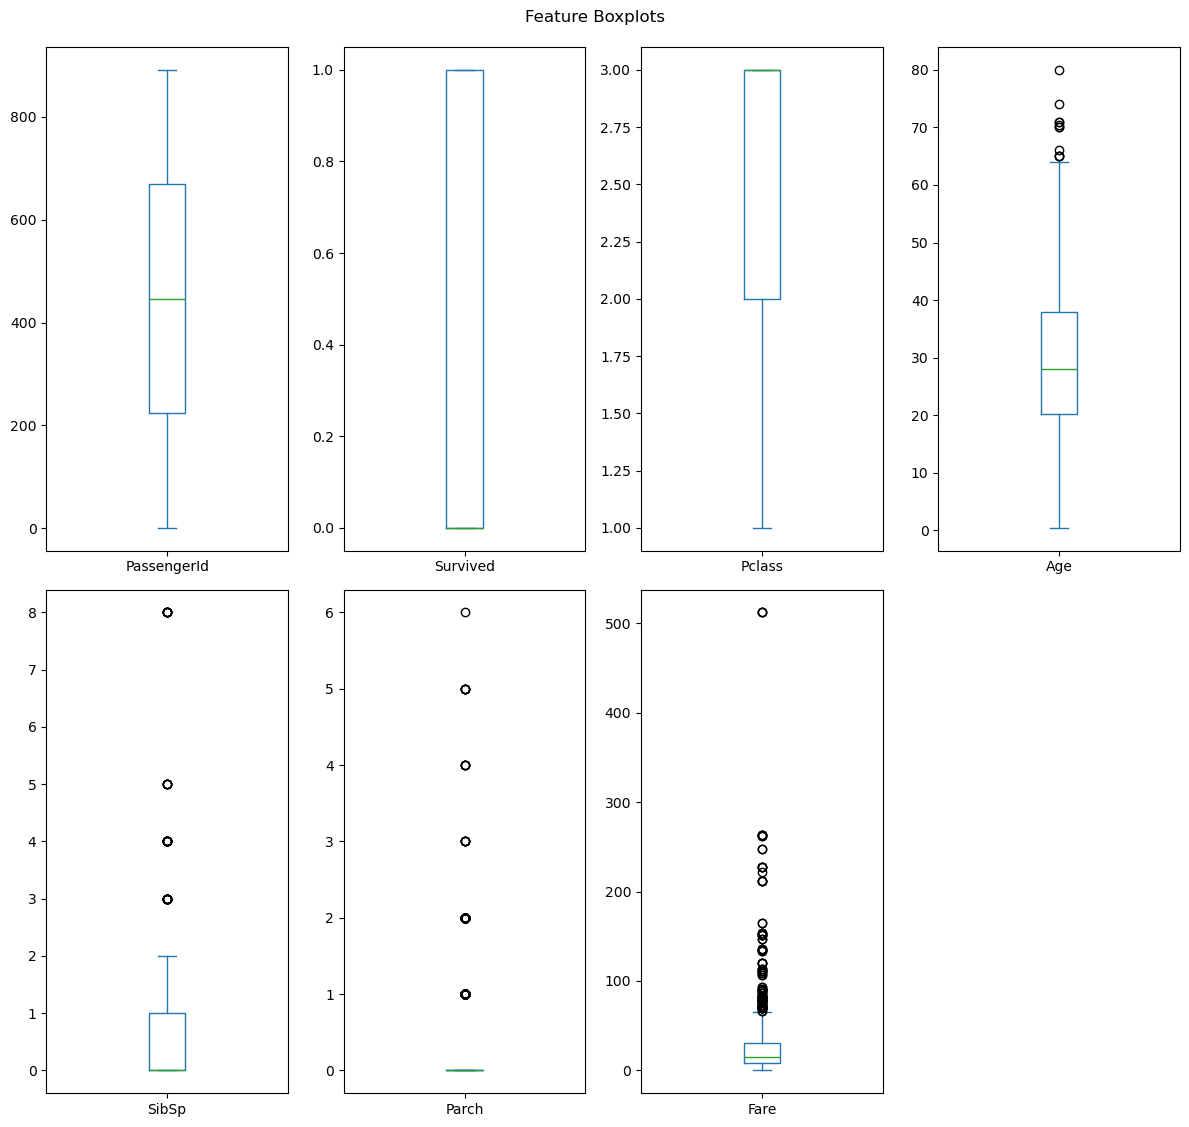

In [165]:
# Boxplot
train_data.plot(kind='box', figsize=(12,11), subplots=True, layout=(2, 4), sharex=False)
# sns.boxplot(data=train_data, orient='h', palette='Set2', width=0.6)
plt.tight_layout()
plt.suptitle('Feature Boxplots', y=1.02)
# Save the figure
plt.savefig(f"{path_figures}/feature_boxplots.png")
plt.show()

- Comment:
    + Có khá nhiều outlier ở 'fare', các giá trị phân phối không đều. 

### Đa biến

<Figure size 2000x1200 with 0 Axes>

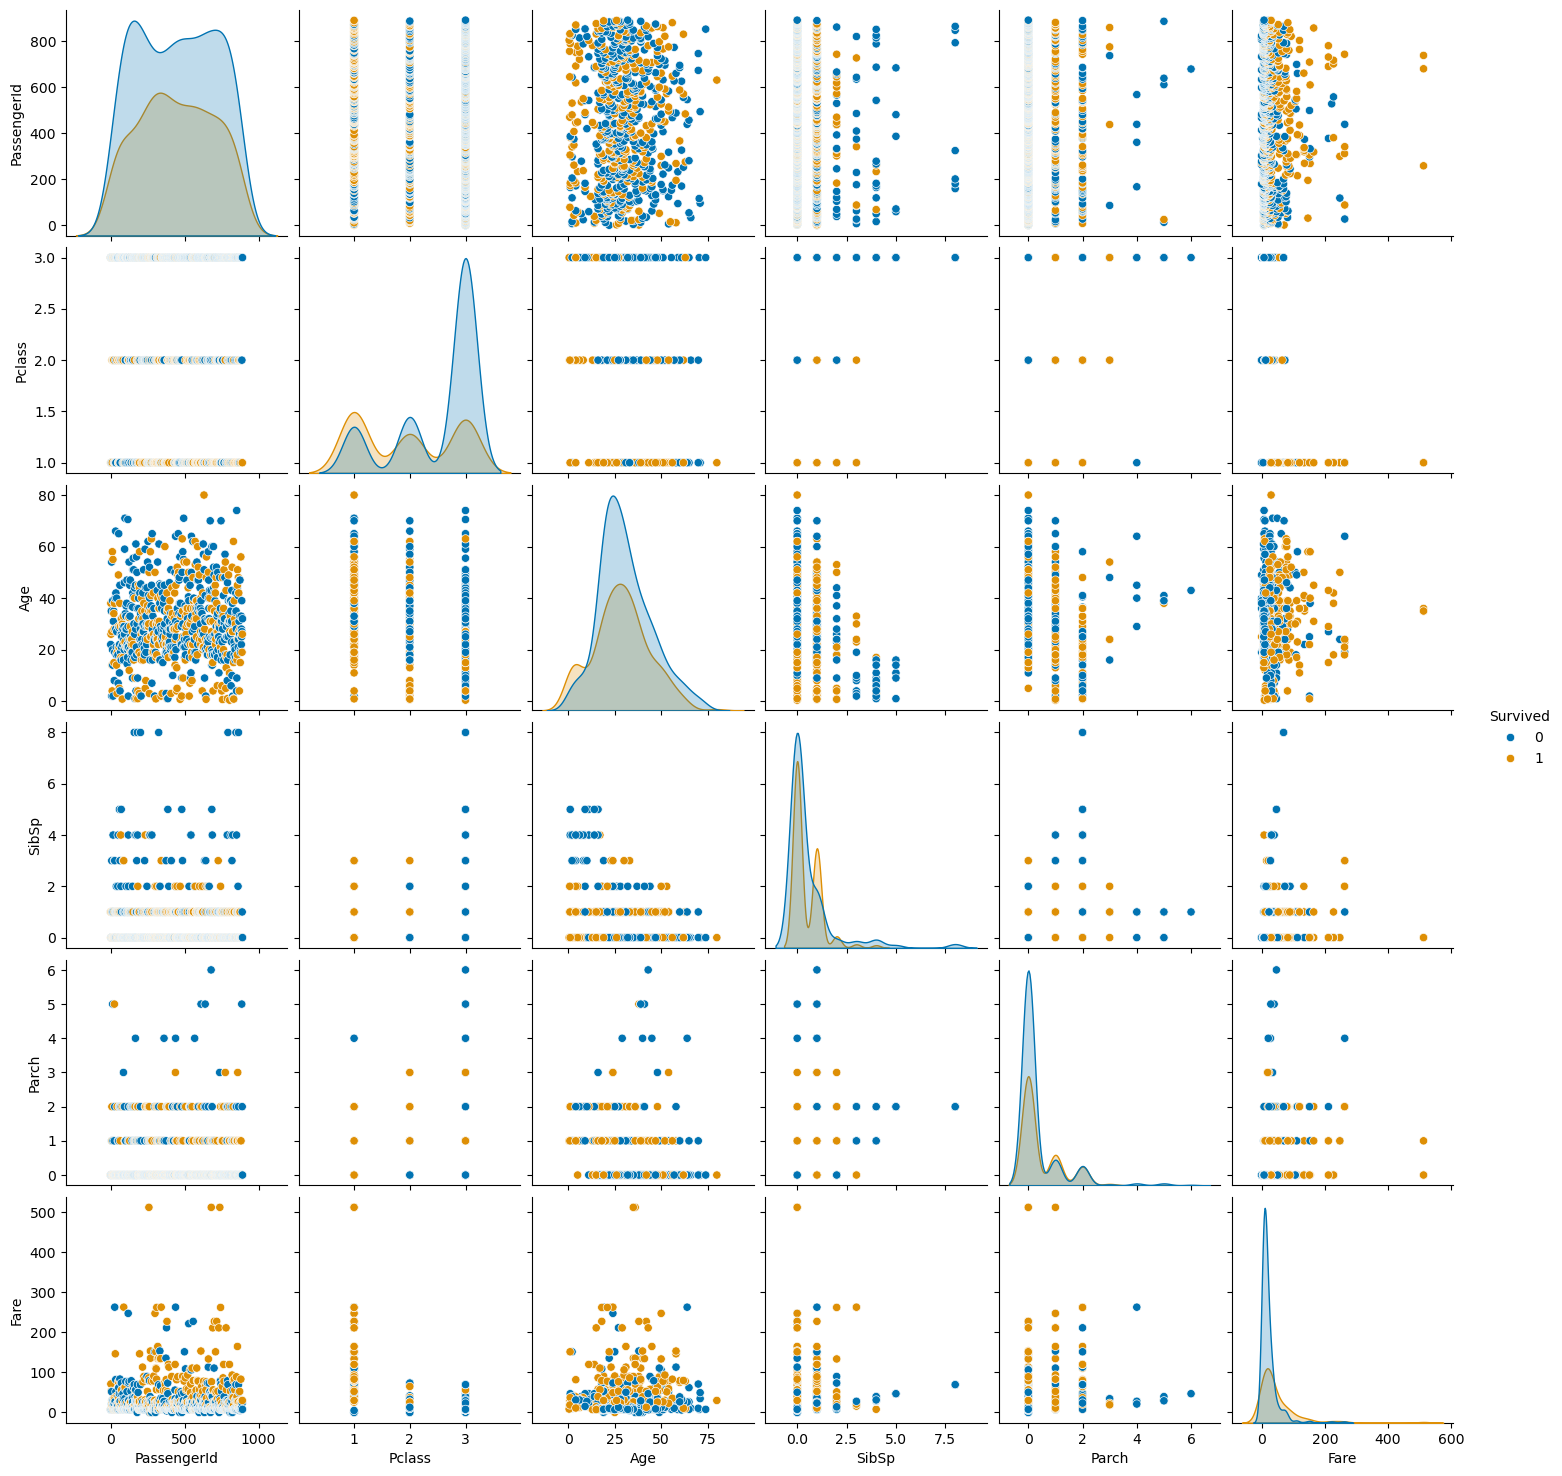

In [166]:
# Scatter matrix plot:
plt.figure(figsize=(20, 12))
sns.pairplot(train_data, hue='Survived', palette='colorblind')
plt.show();

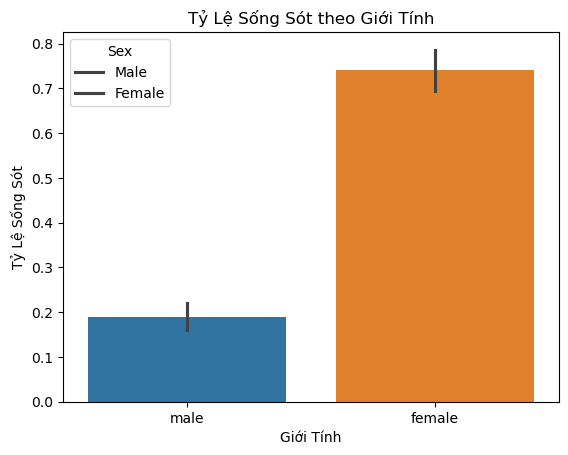

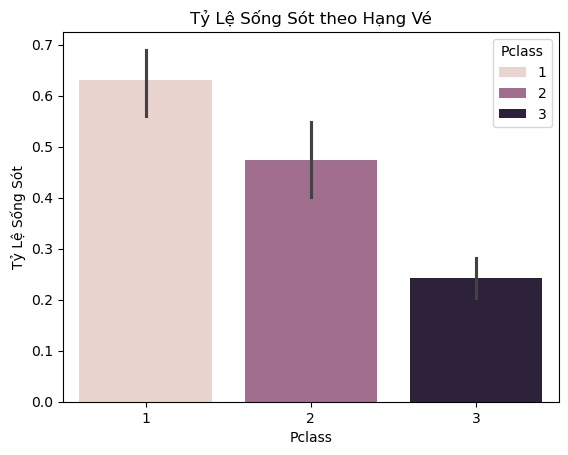

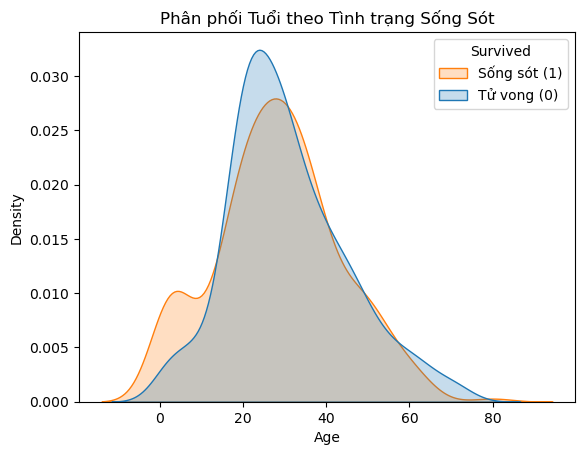

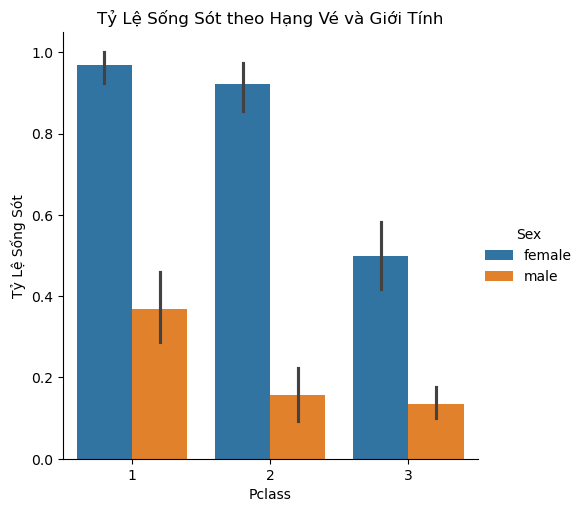

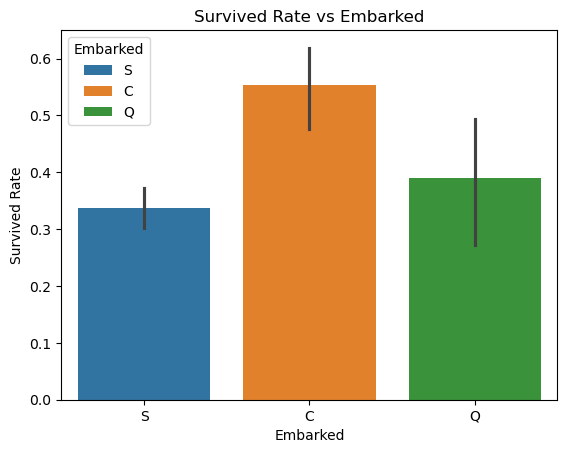

In [167]:
# Survived vs. Sex
sns.barplot(x='Sex', y='Survived', hue='Sex', data=train_data)
plt.xlabel('Giới Tính')
plt.ylabel('Tỷ Lệ Sống Sót')
plt.title('Tỷ Lệ Sống Sót theo Giới Tính')
plt.legend(title='Sex', labels=['Male', 'Female'])
# Save the figure
plt.savefig(f"{path_figures}/survived_vs_sex.png")
plt.show()
# Insight: Nữ giới có tỷ lệ sống sót cao hơn hẳn.

# Survived vs. Pclass
sns.barplot(x='Pclass', y='Survived', hue='Pclass', data=train_data)
plt.title('Tỷ Lệ Sống Sót theo Hạng Vé')
plt.ylabel('Tỷ Lệ Sống Sót')
# Save the figure
plt.savefig(f"{path_figures}/survived_vs_pclass.png")
plt.show()
# Insight: Hạng vé càng cao (1) thì tỷ lệ sống sót càng cao.

# Survived vs. Age (dùng KDE plot)
sns.kdeplot(data=train_data, x='Age', hue='Survived', fill=True, common_norm=False)
plt.title('Phân phối Tuổi theo Tình trạng Sống Sót')
plt.legend(title='Survived', labels=['Sống sót (1)', 'Tử vong (0)'])
# Save the figure
plt.savefig(f"{path_figures}/survived_vs_age_kde.png")
plt.show()
# Insight: Có một đỉnh rõ rệt ở nhóm trẻ em (<10 tuổi) có tỷ lệ sống sót cao.

# Phân tích kết hợp: Survived vs. Pclass và Sex
sns.catplot(x='Pclass', y='Survived', hue='Sex', kind='bar', data=train_data)
plt.title('Tỷ Lệ Sống Sót theo Hạng Vé và Giới Tính')
plt.ylabel('Tỷ Lệ Sống Sót')
# Save the figure
plt.savefig(f"{path_figures}/survived_vs_pclass_sex.png")
plt.show()
# Insight: Nữ giới ở mọi hạng vé đều có tỷ lệ sống sót cao hơn nam giới. Nữ giới ở hạng 1 và 2 có tỷ lệ sống sót rất cao.

sns.barplot(x='Embarked', y='Survived', hue='Embarked', data=train_data)
plt.xlabel('Embarked')
plt.ylabel('Survived Rate')
plt.title('Survived Rate vs Embarked')
# Save the figure
plt.savefig(f"{path_figures}/survived_vs_embarked.png") 
plt.show()

- Comment: 
    + Giới tính: Female có khả năng sống sót cao hơn đáng kể so với Male
    + Pclass: hạng càng thấp (càng cao cấp) thì tỉ lê sống càng cao
    + Độ tuổi: chỉ có tuổi khoảng từ 0-10 là có tỉ lệ sống cao hơn, còn các độ tuổi khác thì khả năng sống sót hay không gần như giống nhau.
    + 'Embarked': C(Cherbourg) có tỉ lệ sống >50%, các cảng còn lại đều dưới.

### Phân tích các non-numerical features

In [168]:
# non-numerical features: Name, Sex, Ticket, Cabin, Embarked
non_numerical_features = train_data.select_dtypes(include=['object']).columns

# Show non-numerical features, 20 rows
train_data[non_numerical_features].tail(20)

,Name,Sex,Ticket,Cabin,Embarked
871,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,11751,D35,S
872,"Carlsson, Mr. Frans Olof",male,695,B51 B53 B55,S
873,"Vander Cruyssen, Mr. Victor",male,345765,NaN,S
874,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,P/PP 3381,NaN,C
875,"Najib, Miss. Adele Kiamie ""Jane""",female,2667,NaN,C
876,"Gustafsson, Mr. Alfred Ossian",male,7534,NaN,S
877,"Petroff, Mr. Nedelio",male,349212,NaN,S
878,"Laleff, Mr. Kristo",male,349217,NaN,S
879,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,11767,C50,C
880,"Shelley, Mrs. William (Imanita Parrish Hall)",female,230433,NaN,S


- Comment:
    + 'Name': mỗi người có một subname (title) hay danh xưng khác nhau, điều này có thể ảnh hưởng đến khả năng sống sót vì nó thể hiện thông tin, địa vị của người đó.
    + 'Cabin': hầu hết đều thiếu. Nhưng có phải những người có thông tin cabin là những người còn sống sót? 

In [169]:
# Survived and Cabin, 20 rows
train_data[['Survived', 'Cabin']].tail(20)

,Survived,Cabin
871,1,D35
872,0,B51 B53 B55
873,0,NaN
874,1,NaN
875,1,NaN
876,0,NaN
877,0,NaN
878,0,NaN
879,1,C50
880,1,NaN


- Comment: nhận định trên có thể đúng

# **K-fold**

--- 
Nhận thấy dataset khá nhỏ, vậy nên ta dùng K-fold CV với k=10. 
Sau đó preprocessing trong fold

K-fold để chia data thành 10 fold (k=10) và tiến hành

- Preprocessing
- Features engineering trong fold

---

In [170]:
from sklearn import model_selection as skl_model_select 
from sklearn import pipeline as skl_pipeline
from sklearn import compose as skl_compose
from sklearn import impute as skl_impute
from sklearn import preprocessing as skl_pre
from sklearn import linear_model as skl_linmodel
from sklearn import ensemble as skl_ensemble
from sklearn import feature_selection as skl_f_select
import xgboost as xgb

# Class FeatureEngineering & OutlierHandler
from sklearn import base as skl_base
import re # for regex 

## Split data to X and y (target)

In [171]:
# Split data to X,y
X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

X.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0000,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0000,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0000,0,0,373450,8.0500,NaN,S


# 2. Data preprocessing

## 2.1 Remove duplicated samples 

In [172]:
# Remove duplicated
data_dup = train_data[train_data.duplicated(keep='first')]
print(data_dup)

Empty DataFrame
Columns: [PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []


- Comment: không có dữ liệu bị trùng lặp
  

## 2.2 Drop columns

Xóa những cột: 
1. PassengerID
2. /

In [173]:
# Drop columns that are not useful for prediction
features_to_drop = ["PassengerId"]
X = X.drop(columns=features_to_drop)

print(f"Dropped features: {features_to_drop}")

Dropped features: ['PassengerId']


## 2.3 Filling missing values

| Features    | Strategy     |
|-------------|--------------|
| Age         |  median      |
| Cabin       |  random value: 'Z'         |
| Embarked       |  most frequency         |


## 2.4 Handle outlier

| Features    | Strategy     |
|-------------|--------------|
| Age         |  all outlier transform to 75th percentiles      |
| Fare        |  the highest -> the second highest(about 270)  |
| SibSp       |  the highest -> the second highest(about 5)         |


## 2.5 Scale, transform features

- Transform:

| Features    | Strategy     |
|-------------|--------------|
| Sex         |  OrdinalEncoder      |
| Embarked    |  OrdinalEncoder      |
| Pclass    |  OrdinalEncoder      |

- Scale:

| Features    | Strategy     |
|-------------|--------------|
| Age         |  Standardize      |
| Fare        |  Standardize         |
| SibSp        |  Standardize         |
| Parch        |  Standardize         |




## 2.5 Feature construction

| New features    | Strategy, details     |
|-------------|--------------|
| Ticket         |  Standardize      |



## Implement in code:

In [ ]:

class OutlierHandler(skl_base.BaseEstimator, skl_base.TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        """
        fit() học (tính) các ngưỡng giới hạn outlier trên dữ liệu huấn luyện.
        """
        
        # === 1. Age: tính giá trị phần tư thứ 3 (75th percentile) ===
        # Nghĩa là: 75% dữ liệu Age nhỏ hơn ngưỡng này.
        # Các giá trị lớn hơn ngưỡng này được coi là outlier (già bất thường).
        self.age_cap_ = X['Age'].quantile(0.75)

        # === 2. Fare: lấy giá trị cao thứ 2 trong cột Fare ===
        # Vì trong X có vài giá vé cực cao (512, 263,...),
        # ta thay giá trị cao nhất bằng giá trị cao thứ 2 để giảm ảnh hưởng outlier.
        # np.sort(...)[-2] nghĩa là lấy phần tử thứ 2 từ cuối.
        # Nếu chỉ có 1 giá trị duy nhất thì dùng giá trị đó (max).
        self.fare_cap_ = (
            np.sort(X['Fare'].dropna().unique())[-2]  # phần tử cao thứ 2
            if X['Fare'].nunique() > 1                # nếu có hơn 1 giá trị duy nhất
            else X['Fare'].max()                      # nếu chỉ có 1 giá trị
        )

        # === 3. SibSp: lấy giá trị cao thứ 2 trong cột SibSp (số anh chị em/người thân đi cùng) ===
        # Vì đôi khi có hành khách đi cùng rất nhiều người (hiếm gặp),
        # ta cắt giá trị cao nhất xuống mức hợp lý hơn (giá trị cao thứ 2).
        self.sibsp_cap_ = (
            np.sort(X['SibSp'].dropna().unique())[-2]
            if X['SibSp'].nunique() > 1
            else X['SibSp'].max()
        )

        # Trả lại chính object này để scikit-learn có thể chain tiếp trong pipeline
        return self

    def transform(self, X):
        """
        transform() áp dụng ngưỡng đã học ở fit() để cắt (cap) các giá trị outlier.
        Nếu giá trị vượt quá ngưỡng, ta thay bằng ngưỡng.
        """
        X = X.copy()

        # === 1. Age ===
        # Nếu Age > ngưỡng 75th percentile (self.age_cap_) thì gán bằng self.age_cap_
        X['Age'] = np.where(X['Age'] > self.age_cap_, self.age_cap_, X['Age'])

        # === 2. Fare ===
        # Nếu Fare > ngưỡng cap (giá trị cao thứ 2) thì gán bằng self.fare_cap_
        X['Fare'] = np.where(X['Fare'] > self.fare_cap_, self.fare_cap_, X['Fare'])

        # === 3. SibSp ===
        # Nếu SibSp > ngưỡng cap (giá trị cao thứ 2) thì gán bằng self.sibsp_cap_
        X['SibSp'] = np.where(X['SibSp'] > self.sibsp_cap_, self.sibsp_cap_, X['SibSp'])

        # Trả về DataFrame đã xử lý outlier
        return X

# initialize OutlierHandler
outlier_handler = OutlierHandler()

In [175]:


class FeatureEngineering(skl_base.BaseEstimator, skl_base.TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        ### 1. Relationship: 'SibSp' + 'Parch'
        X['Relationship'] = X['SibSp'] + X['Parch'] + 1

        ### 1.1. IsAlone: Relationship == 0
        X['IsAlone'] = (X['Relationship'] == 1).astype(int)

        ### 2. Get Title from 'Name'
        def extract_title(name):
            match = re.search(r' ([A-Za-z]+)\.', name)
            if match:
                return match.group(1)
            return "Unknown"
        X['Title'] = X['Name'].apply(extract_title)
    
        # Group some rare Title -> 'Rare'
        common_titles = ['Mr', 'Mrs', 'Miss', 'Master']
        X['Title'] = X['Title'].apply(lambda t: t if t in common_titles else 'Rare')
        # X['Title'] = X['Name'].str.split(", ", expand=True)[1].str.split(".", expand=True)[0]

    
        ### Get Deck from 'Cabin' (low cardinality: A-G, T, Z)
        # X['Cabin'] = X['Cabin'].fillna('Z')
        # X['Deck'] = X['Cabin'].astype(str).apply(lambda x: x[0] if pd.notna(x) else 'Z')
        X['Deck'] = X['Cabin'].fillna('Z').str[0]

        ### 3. has_cabin?
        # X["has_cabin"] = np.where(X["Cabin"].notna(), 1, 0)
        # X['Cabin'] = X['Cabin'].fillna('Z')

        ### 4. male_rich: 
        X['male_rich'] = ((X['Sex'] == 'male') & (X['Fare'] > 50)).astype(int)

        ## 5. child_one: with <= 1 parent/sib
        # X['child_one'] = ((X['Title'] == 'Master') & (X['Relationship'] <= 1)).astype(int)
        ## 5. Woman | child
        X['Woman_child'] = ((X['Sex'] == 'female') | (X['Title'] == 'Master')).astype(int)

        ### 6. Encode Embarked: S-0, C-1, Q-2
        embarked_map = {'S': 0, 'C': 1, 'Q': 2}
        X['Embarked'] = X['Embarked'].map(embarked_map)

        # 7. Fare bins
        # X['Fare'] = X['Fare'].fillna(X['Fare'].median())
        # X['Fare_bins'] = pd.cut(
        #     X['Fare'],
        #     bins=[-1, 8, 15, 30, 50, 9999],
        #     labels=[0, 1, 2, 3, 4]
        # ).astype(int)

        # 8. Age bins
        # X['Age'] = X['Age'].fillna(X['Age'].median())
        # X['Age_bins'] = pd.cut(
        #     X['Age'],
        #     bins=[-1, 18, 32, 64, 9999],
        #     labels=[0, 1, 2, 3]
        # ).astype(int)

        # 9. Ticket count:
        X['Ticket_freq'] = X.groupby('Ticket')['Ticket'].transform('count')

        # 10. Fare per person
        X['Fare_per_person'] = X['Fare'] / X['Ticket_freq']


        # Drop all redundant columns:
        # X = X.drop(columns=['SibSp', 'Parch', 'Cabin', 'Name', 'Fare', 'Age'])
        # X = X.drop(columns=['SibSp', 'Parch', 'Name', 'Fare', 'Age'])
        X = X.drop(columns=['SibSp', 'Parch', 'Name', 'Cabin', 'Ticket'])

        
        return X

# Instantiate the feature engineering transformer    
feature_engineering = FeatureEngineering()


In [176]:
# Các cột filling missing values
filling_missing_age = ['Age']
filling_missing_cabin = ['Cabin']
filling_missing_embarked = ['Embarked']

scaling_standardize_features = ['Fare', 'SibSp', 'Parch']  # bỏ Age ra (đã xử lý riêng)
transform_ordinal_features = ['Sex','Pclass']


In [177]:

# --- FILLING MISSING VALUES --- #
filling_missing_age_pipeline = skl_pipeline.Pipeline([
    ('impute', skl_impute.SimpleImputer(strategy='median'))
])

# Cabin có nhiều missing, nên ta:
# 1. điền 'Z' cho missing,
# 2. Ordinal encode cabin (thành số)
filling_missing_cabin_pipeline = skl_pipeline.Pipeline([
    ('impute', skl_impute.SimpleImputer(strategy='constant', fill_value='Z')),
    ('encode', skl_pre.OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Embarked: thay thế missing bằng giá trị phổ biến nhất
filling_missing_embarked_pipeline = skl_pipeline.Pipeline([
    ('impute', skl_impute.SimpleImputer(strategy='most_frequent')),
    ('encoder', skl_pre.OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

# --- SCALING & TRANSFORMING --- #
scaling_standardize_pipeline = skl_pipeline.Pipeline([
    ('scaler', skl_pre.StandardScaler())
])

transform_ordinal_pipeline = skl_pipeline.Pipeline([
    ('encoder', skl_pre.OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

# --- COMBINE ALL --- #
preprocessor = skl_compose.ColumnTransformer([
    ('age', filling_missing_age_pipeline, filling_missing_age),
    ('cabin', filling_missing_cabin_pipeline, filling_missing_cabin),
    ('embarked', filling_missing_embarked_pipeline, filling_missing_embarked),
    ('scaling_standardize', scaling_standardize_pipeline, scaling_standardize_features),
    ('transform_ordinal', transform_ordinal_pipeline, transform_ordinal_features)
])


In [178]:
# pipeline (tổng quát)
pipeline = skl_pipeline.Pipeline([
    # Outlier handling
    ('outlier', outlier_handler),
    # ('feature_engineering', feature_engineering),  
    ('preprocess', preprocessor),
    # SelectKBest with ANOVA, to select k=10 best features
    # ('selector', skl_f_select.SelectKBest(skl_f_select.f_classif, k=10)),  # k=10
    ('model', skl_linmodel.LogisticRegression(max_iter=1000))
])

# 3. Training 

## 3.1 Check our data before training

In [179]:
# Show data (X) after feature_engineering & preprocessing
X_original = X.copy()

# After Feature Engineering
# X_after_feature = pipeline.named_steps['feature_engineering'].transform(X_original)
# print("=== Sau bước feature_engineering ===")
# print(X_after_feature.head())
# print(X_after_feature.columns)

# After Preprocess (OrdinalEncoder + Imputer)
# X_after_preprocess = pipeline.named_steps['preprocess'].fit_transform(X_after_feature)
X_after_preprocess = pipeline.named_steps['preprocess'].fit_transform(X_original)
print("\n=== Sau bước preprocess ===")
# print(X_after_preprocess[:5])   # numpy
feature_names = (
    pipeline.named_steps['preprocess']
    .get_feature_names_out()
)
X_after_preprocess_df = pd.DataFrame(
    X_after_preprocess,
    columns=feature_names
)

X_after_preprocess_df.head(10)


=== Sau bước preprocess ===


,age__Age,cabin__Cabin,embarked__Embarked,scaling_standardize__Fare,scaling_standardize__SibSp,scaling_standardize__Parch,transform_ordinal__Sex,transform_ordinal__Pclass
0,22.0000,147.0000,2.0000,-0.5024,0.4328,-0.4737,1.0000,2.0000
1,38.0000,81.0000,0.0000,0.7868,0.4328,-0.4737,0.0000,0.0000
2,26.0000,147.0000,2.0000,-0.4889,-0.4745,-0.4737,0.0000,2.0000
3,35.0000,55.0000,2.0000,0.4207,0.4328,-0.4737,0.0000,0.0000
4,35.0000,147.0000,2.0000,-0.4863,-0.4745,-0.4737,1.0000,2.0000
5,28.0000,147.0000,1.0000,-0.4781,-0.4745,-0.4737,1.0000,2.0000
6,54.0000,129.0000,2.0000,0.3958,-0.4745,-0.4737,1.0000,0.0000
7,2.0000,147.0000,2.0000,-0.2241,2.2475,0.7676,1.0000,2.0000
8,27.0000,147.0000,2.0000,-0.4243,-0.4745,2.0089,0.0000,2.0000
9,14.0000,147.0000,0.0000,-0.0430,0.4328,-0.4737,0.0000,1.0000


In [181]:
# STOP CODE
# the quick brown fox jumps over the lazy dog

## 3.2 Training

In [ ]:
SEED_RANDOM_FOREST = 42
LOGISTIC_REG_MAX_ITER = 10000

param_grid = [
    # Logistic Regression
    {
        "model": [skl_linmodel.LogisticRegression(max_iter=LOGISTIC_REG_MAX_ITER)],
        "model__C": [0.1, 1.0, 10],
        "model__solver": ["lbfgs", "liblinear"]
    },

    # Random Forest
    {
        "model": [skl_ensemble.RandomForestClassifier(random_state=SEED_RANDOM_FOREST)],
        "model__n_estimators": [70, 100, 200],
        "model__max_depth": [3, 5, 10]
    },

    # XGBoost
    {
        "model": [xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')],
        "model__n_estimators": [70, 100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 5]
    }
]

In [183]:
K_FOLD = 5
SEED_K_FOLD = 21

# Cross validation: K-fold
cv = skl_model_select.StratifiedKFold(n_splits=K_FOLD, shuffle=True, random_state=SEED_K_FOLD)

grid_search = skl_model_select.GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    
    scoring={
        'accuracy': 'accuracy',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    },
    
    refit='f1', # use 'f1' metric to choose best model

    # Using all CPU 
    n_jobs=-1, # number of threads run in paralell 
    
    # verbose: 0-quite, 1-short, 2-detail
    verbose=0, # print detail log

    error_score='raise'  # stacktrace chi tiết

)


In [184]:
# Training
grid_search.fit(X, y)

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"[{'model': [LogisticRegre...ax_iter=10000)], 'model__C': [0.1, 1.0, ...], 'model__solver': ['lbfgs', 'liblinear']}, {'model': [RandomForestC...ndom_state=42)], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [70, 100, ...]}, ...]"
,scoring,"{'accuracy': 'accuracy', 'f1': 'f1', 'roc_auc': 'roc_auc'}"
,n_jobs,-1
,refit,'f1'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,transformers,"[('age', ...), ('cabin', ...), ...]"


In [185]:
print("✅ Best Model:", grid_search.best_estimator_)
print("✅ Best Params:", grid_search.best_params_)
print(f"✅ Best Accuracy: {grid_search.best_score_:.4f}")

✅ Best Model: Pipeline(steps=[('outlier', OutlierHandler()),
                ('preprocess',
                 ColumnTransformer(transformers=[('age',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age']),
                                                 ('cabin',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='Z',
                                                                                 strategy='constant')),
                                                                  ('encode',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                              

### Compare our models 

In [186]:
# Lấy toàn bộ kết quả
results = pd.DataFrame(grid_search.cv_results_)

# Chỉ lấy các cột quan trọng
cols = [
    "param_model", 
    "mean_test_accuracy", 
    "mean_test_f1", 
    "mean_test_roc_auc", 
    "rank_test_f1"
]
results = results[cols].sort_values(by="rank_test_f1")

# Hiển thị 5 model có f1 tốt nhất
print(results.head())


                                          param_model  mean_test_accuracy  \
14            RandomForestClassifier(random_state=42)              0.8249   
12            RandomForestClassifier(random_state=42)              0.8216   
22  XGBClassifier(base_score=None, booster=None, c...              0.8193   
13            RandomForestClassifier(random_state=42)              0.8193   
26  XGBClassifier(base_score=None, booster=None, c...              0.8138   

    mean_test_f1  mean_test_roc_auc  rank_test_f1  
14        0.7594             0.8659             1  
12        0.7515             0.8662             2  
22        0.7514             0.8684             3  
13        0.7509             0.8655             4  
26        0.7508             0.8658             5  


In [200]:
# Lấy tên class của model (vd: LogisticRegression, RandomForestClassifier, XGBClassifier)
results["model_name"] = results["param_model"].apply(lambda x: type(x).__name__)

# Tính trung bình các metric theo model
summary = results.groupby("model_name")[["mean_test_accuracy", "mean_test_f1", "mean_test_roc_auc"]].mean().reset_index()

display.display(summary)


,model_name,mean_test_accuracy,mean_test_f1,mean_test_roc_auc
0,LogisticRegression,0.7969,0.7182,0.8472
1,RandomForestClassifier,0.8103,0.7241,0.8647
2,XGBClassifier,0.8146,0.7440,0.8671


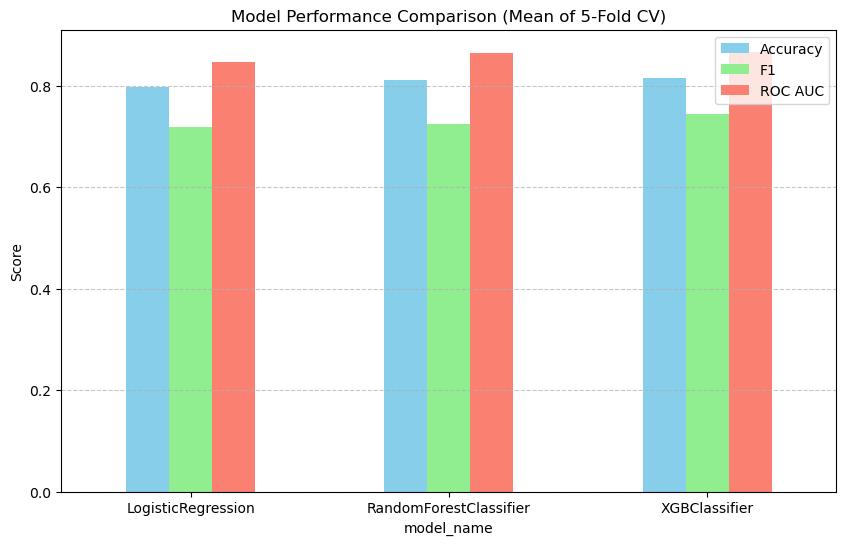

In [188]:
metrics = ["mean_test_accuracy", "mean_test_f1", "mean_test_roc_auc"]

summary.plot(
    x="model_name",
    y=metrics,
    kind="bar",
    figsize=(10,6),
    color=["skyblue", "lightgreen", "salmon"]
)

plt.title("Model Performance Comparison (Mean of 5-Fold CV)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(["Accuracy", "F1", "ROC AUC"])
# Save the figure
# Name the figure with file name & timestamp
plt.savefig(f"{path_figures}/model_performance_comparison_column_{filename}_{timestamp}.png")
plt.show()


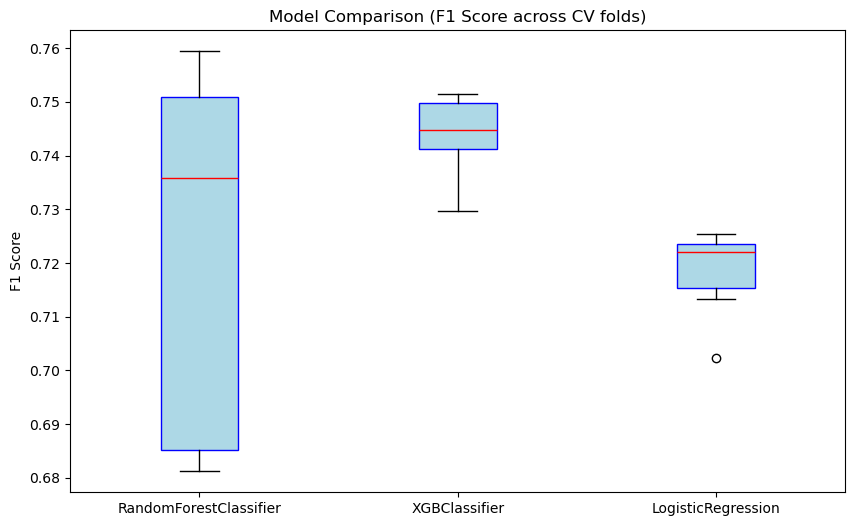

In [189]:

# Lấy dữ liệu điểm từng fold
model_names = results["model_name"].unique()
box_data = []

for name in model_names:
    subset = results[results["model_name"] == name]
    box_data.append(subset["mean_test_f1"])

plt.figure(figsize=(10,6))
plt.boxplot(box_data, labels=model_names, patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="blue"),
            medianprops=dict(color="red"))
plt.title("Model Comparison (F1 Score across CV folds)")
plt.ylabel("F1 Score")
# Save the figure
# plt.savefig(f"{path_figures}/model_f1_boxplot_{filename}_{timestamp}.png")
plt.savefig(f"{path_figures}/model_performance_comparison_boxplot_{filename}_{timestamp}.png")
plt.show()


# 4. Check the test set and predict

In [190]:
test_data = pd.read_csv("./test.csv")

In [191]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5000,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0000,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0000,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0000,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0000,1,1,3101298,12.2875,NaN,S


In [192]:
test_data = test_data.drop(columns=["Name", "PassengerId"])

In [193]:
# Lấy model tốt nhất từ GridSearchCV
best_model = grid_search.best_estimator_

# Dự đoán kết quả trên test
y_pred = best_model.predict(test_data)


In [194]:
# Set the submission file name: submission_yyyymmddhhmmss.csv

submission_file = f"submission_{filename}_{timestamp}.csv"


In [195]:
# Titanic test.csv có cột PassengerId cần giữ lại
submission = pd.DataFrame({
    "PassengerId": pd.read_csv("./test.csv")["PassengerId"],
    "Survived": y_pred
})

submission.to_csv(submission_file, index=False)
print(f"✅ Submission file saved as {submission_file}")


✅ Submission file saved as submission_hello-titanic_V5_*_20251024091040.csv


In [199]:
submission.tail()

,PassengerId,Survived
413,1305,0
414,1306,1
415,1307,0
416,1308,0
417,1309,1
